# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf
import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.utils import PyDataset

def get_stl10_memmap():
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )
    base_dir = os.path.dirname(path)
    filepath = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary', 'unlabeled_X.bin')

    # STL-10: 100,000 images, 3 channels, 96x96
    # We use memmap to avoid loading the file into RAM
    # Shape is (N, C, H, W) based on STL-10 binary format
    shape = (100000, 3, 96, 96)
    images_mmap = np.memmap(filepath, dtype='uint8', mode='r', shape=shape)

    return images_mmap

class PatchGenerator(PyDataset):
    def __init__(self, images_mmap, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # Store the pointer to the memmap, keep it as uint8
        self.images = images_mmap
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")
        Y_order = np.zeros((actual_batch_size, 9), dtype="float32")
        for i, img_idx in enumerate(batch_indices):
            # 1. Load from disk/cache only what we need
            # 2. Transpose from (C, H, W) to (H, W, C)
            # 3. Convert to float and normalize ONLY this one image
            img_cxhxw = self.images[img_idx]
            full_img = img_cxhxw.transpose(2, 1, 0).astype("float32") / 255.0

            Y[i] = full_img

            # Patch extraction logic
            patches = []
            for r in range(3):
                for c in range(3):
                    y_s, x_s = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_s:y_s+self.patch_size, x_s:x_s+self.patch_size, :]

                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin:margin+self.crop_size, margin:margin+self.crop_size, :]
                    patches.append(patch)

            order = np.random.permutation(9)
            Y_order[i] = order.astype("float32")
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, {
            'reconstruction': Y,
            'ordering': Y_order
        }

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
# Trigger the download and loading
images = get_stl10_memmap()
print(f"Successfully downloaded and memory mapped {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 66s 0us/step
Successfully downloaded and memory mapped 100000 images.


In [ ]:
print(images.shape)

(100000, 3, 96, 96)


In [ ]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [ ]:
train_generator = PatchGenerator(train_images, batch_size=64)
val_generator = PatchGenerator(val_images, batch_size=64)
test_generator = PatchGenerator(test_images, batch_size=64)

Let us inspect the dataset.

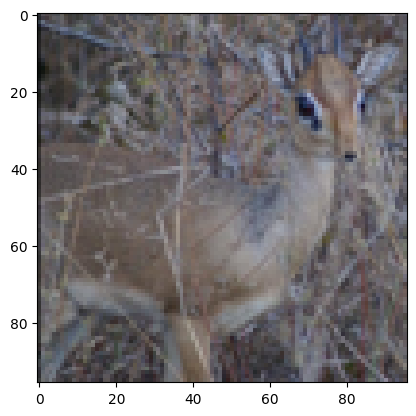

In [ ]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(np.transpose(test_images[n],(2,1,0)))

Let us now visualize the puzzle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [ ]:
a,b = test_generator.__getitem__(1)

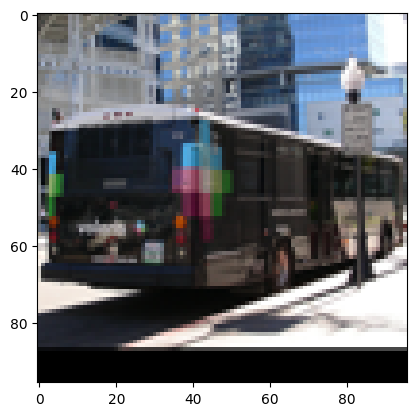

In [ ]:
plt.imshow(b['reconstruction'][4])

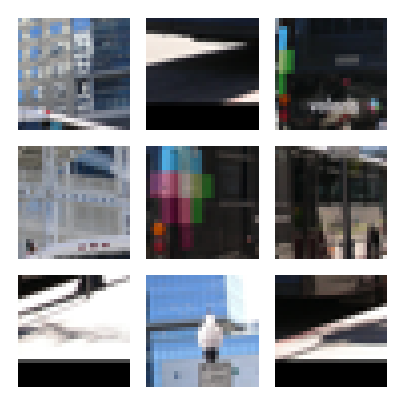

In [ ]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# ARCHITECTURE — FULLY NEURAL JIGSAW PIPELINE
#
# Three stages, zero hardcoded geometry, zero fixed algorithms:
#
#   Stage 1 — Transformer ordering network
#             CNN encodes each patch → Transformer contextualises
#             all 9 → Dense head produces (B, 9, 9) logits
#
#   Stage 2 — NeuralPlacementLayer  [28 learned parameters]
#             Double-Softmax over logits → soft assignment matrix
#             Bilinear STN places each composed patch at LEARNED
#             coordinates (position_coords, placement_scale)
#             Output: (B, 96, 96, 4) canvas + mask
#
#   Stage 3 — U-Net reconstruction network
#             Inpaints the canvas gaps, outputs (B, 96, 96, 3)
#
# Total trainable params: ~2.14M  (budget: 6M)
# Neural credentials of each component listed inline below.
# ═══════════════════════════════════════════════════════════════════════


# ── Stage 1a: shared patch encoder ──────────────────────────────────

def build_patch_encoder(embed_dim=128):
    """
    CNN: (28, 28, 3) → (embed_dim,)
    Shared weights across all 9 patches via TimeDistributed.
    """
    inp = layers.Input(shape=(28, 28, 3))

    x = layers.Conv2D(32, 3, padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)                    # 14×14

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)                    # 7×7

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(embed_dim, activation='relu')(x)
    x = layers.LayerNormalization()(x)

    return models.Model(inp, x, name='patch_encoder')


# ── Stage 1b: transformer ordering network ──────────────────────────

def build_ordering_network(embed_dim=128, num_heads=4,
                           ff_dim=256, num_layers=3):
    """
    (B, 9, 28, 28, 3) → (B, 9, 9) logits

    No positional embedding — patches arrive scrambled so input-slot
    indices are meaningless. Transformer attends over patch CONTENT only.
    Returns raw logits; NeuralPlacementLayer handles assignment.
    """
    patches_input = layers.Input(shape=(9, 28, 28, 3), name='patches')

    patch_encoder = build_patch_encoder(embed_dim)
    x = layers.TimeDistributed(
        patch_encoder, name='shared_encoder')(patches_input)  # (B, 9, 128)

    for i in range(num_layers):
        x_norm   = layers.LayerNormalization(name=f'ln1_{i}')(x)
        attn_out = layers.MultiHeadAttention(
            num_heads = num_heads,
            key_dim   = embed_dim // num_heads,
            dropout   = 0.1,
            name      = f'mha_{i}'
        )(x_norm, x_norm)
        x = x + layers.Dropout(0.1, name=f'drop_a_{i}')(attn_out)

        x_norm = layers.LayerNormalization(name=f'ln2_{i}')(x)
        ff     = layers.Dense(ff_dim, activation='gelu', name=f'ff1_{i}')(x_norm)
        ff     = layers.Dropout(0.1, name=f'drop_f_{i}')(ff)
        ff     = layers.Dense(embed_dim, name=f'ff2_{i}')(ff)
        x      = x + ff

    x      = layers.LayerNormalization(name='final_ln')(x)
    logits = layers.Dense(9, name='position_logits')(x)   # (B, 9, 9)

    return models.Model(patches_input, logits, name='ordering_network')


# ── Stage 2: neural placement layer ─────────────────────────────────

class NeuralPlacementLayer(layers.Layer):
    """
    Fully neural ordering + canvas placement. 28 learned parameters.

    Neural credentials — nothing hardcoded:

    Assignment (replaces Sinkhorn):
        Double-Softmax: softmax over rows × softmax over columns,
        then row-renormalize. Approximates doubly-stochastic without
        any iterative algorithm. One learned temperature scalar
        (log_temp, trained by backprop) controls sharpness.

    Placement (replaces CanvasBuilder's pos//3 arithmetic):
        position_coords  — (9, 2) learned (y, x) centers, initialized
                           to the correct 3×3 grid but fully trainable.
        placement_scale  — (9,) learned scale per position, initialized
                           to patch_size/canvas_size ≈ 0.292.
        Patches placed via bilinear grid sampling (standard STN op).

    Output: (B, 96, 96, 4) — RGB canvas + mask, same as old CanvasBuilder,
            so the U-Net downstream is completely unchanged.
    """

    def __init__(self, n_positions=9, patch_size=28,
                 canvas_size=96, **kwargs):
        super().__init__(**kwargs)
        self.n_positions = n_positions
        self.patch_size  = patch_size
        self.canvas_size = canvas_size

    def build(self, input_shape):

        # Learned temperature — controls assignment sharpness
        # softplus keeps it strictly positive; +1e-3 prevents collapse to 0
        self.log_temp = self.add_weight(
            name='log_temperature', shape=(),
            initializer=tf.constant_initializer(0.0),
            trainable=True)

        # Learned placement coordinates — initialized to 3×3 grid centers
        # in [-1, 1] (STN coordinate space), but fully trainable.
        # This is the direct neural replacement for pos//3 arithmetic.
        cell  = self.canvas_size / 3.0
        inits = []
        for p in range(self.n_positions):
            row = p // 3
            col = p % 3
            y = ((row * cell + cell / 2.0) / self.canvas_size) * 2.0 - 1.0
            x = ((col * cell + cell / 2.0) / self.canvas_size) * 2.0 - 1.0
            inits.append([y, x])
        # NOTE: pos//3 arithmetic used ONCE here to set initial weight values.
        # During every forward pass, only self.position_coords is used.

        self.position_coords = self.add_weight(
            name='position_coords', shape=(self.n_positions, 2),
            initializer=tf.constant_initializer(
                np.array(inits, dtype=np.float32)),
            trainable=True)

        # Learned scale — softplus(raw) + 0.15 ensures strictly positive
        # Initialized so softplus(x) + 0.15 ≈ 0.292 → x ≈ -1.94
        self.placement_scale = self.add_weight(
            name='placement_scale', shape=(self.n_positions,),
            initializer=tf.constant_initializer([-1.94] * self.n_positions),
            trainable=True)

        super().build(input_shape)

    def _assign(self, logits):
        """
        Double-Softmax assignment: fully neural, no iterative algorithm.
        logits: (B, 9, 9) → assignment: (B, 9, 9)
        """
        temp   = tf.math.softplus(self.log_temp) + 1e-3
        scaled = logits / temp

        # Row softmax: each patch sums to 1 across positions
        p_row = tf.nn.softmax(scaled, axis=-1)
        # Col softmax: each position sums to 1 across patches
        p_col = tf.nn.softmax(scaled, axis=-2)

        # Element-wise product penalises duplicate assignments
        w = p_row * p_col

        # Re-normalise rows so canvas mixing weights sum to 1
        assignment = w / (tf.reduce_sum(w, axis=-1, keepdims=True) + 1e-8)
        return assignment

    def _bilinear_sample(self, img, grid):
        """Bilinear grid sampling — standard spatial transformer operation."""
        B     = tf.shape(img)[0]
        H_in  = tf.shape(img)[1]
        W_in  = tf.shape(img)[2]
        H_out = tf.shape(grid)[1]
        W_out = tf.shape(grid)[2]

        x = (grid[..., 0] + 1.0) * tf.cast(W_in - 1, tf.float32) / 2.0
        y = (grid[..., 1] + 1.0) * tf.cast(H_in - 1, tf.float32) / 2.0

        x0 = tf.cast(tf.floor(x), tf.int32)
        y0 = tf.cast(tf.floor(y), tf.int32)
        x1 = x0 + 1
        y1 = y0 + 1

        x0 = tf.clip_by_value(x0, 0, W_in - 1)
        x1 = tf.clip_by_value(x1, 0, W_in - 1)
        y0 = tf.clip_by_value(y0, 0, H_in - 1)
        y1 = tf.clip_by_value(y1, 0, H_in - 1)

        def gather(yi, xi):
            bidx = tf.tile(
                tf.reshape(tf.range(B), (-1, 1, 1)), (1, H_out, W_out))
            return tf.gather_nd(img, tf.stack([bidx, yi, xi], axis=-1))

        Ia = gather(y0, x0);  Ib = gather(y1, x0)
        Ic = gather(y0, x1);  Id = gather(y1, x1)

        x0f = tf.cast(x0, tf.float32);  y0f = tf.cast(y0, tf.float32)
        x1f = tf.cast(x1, tf.float32);  y1f = tf.cast(y1, tf.float32)

        wa = tf.expand_dims((x1f - x)  * (y1f - y),  -1)
        wb = tf.expand_dims((x1f - x)  * (y  - y0f), -1)
        wc = tf.expand_dims((x  - x0f) * (y1f - y),  -1)
        wd = tf.expand_dims((x  - x0f) * (y  - y0f), -1)

        return wa*Ia + wb*Ib + wc*Ic + wd*Id

    def _place_patch(self, patch, y_c, x_c, scale):
        """Place patch on canvas at learned (y_c, x_c) with learned scale."""
        B = tf.shape(patch)[0]
        H = W = self.canvas_size

        gy = tf.linspace(-1.0, 1.0, H)
        gx = tf.linspace(-1.0, 1.0, W)
        grid_x, grid_y = tf.meshgrid(gx, gy)

        py = (grid_y - y_c) / (scale + 1e-8)
        px = (grid_x - x_c) / (scale + 1e-8)

        grid   = tf.stack([px, py], axis=-1)
        grid   = tf.tile(grid[None], [B, 1, 1, 1])
        placed = self._bilinear_sample(patch, grid)

        in_b = tf.cast(
            (tf.abs(py) <= 1.0) & (tf.abs(px) <= 1.0), tf.float32)
        mask = tf.tile(in_b[None, :, :, None], [B, 1, 1, 1])

        return placed, mask

    def call(self, inputs):
        logits, patches_raw = inputs

        assignment = self._assign(logits)           # (B, 9, 9)

        parts_canvas, parts_mask = [], []
        for pos_idx in range(self.n_positions):
            w        = assignment[:, :, pos_idx]
            w        = tf.reshape(w, (-1, 9, 1, 1, 1))
            composed = tf.reduce_sum(w * patches_raw, axis=1)

            # Learned coords — clipped to prevent patches leaving canvas
            y_c   = tf.clip_by_value(
                self.position_coords[pos_idx, 0], -1.2, 1.2)
            x_c   = tf.clip_by_value(
                self.position_coords[pos_idx, 1], -1.2, 1.2)
            scale = tf.math.softplus(
                self.placement_scale[pos_idx]) + 0.15

            placed, mask = self._place_patch(composed, y_c, x_c, scale)
            parts_canvas.append(placed)
            parts_mask.append(mask)

        canvas = tf.add_n(parts_canvas)
        mask   = tf.clip_by_value(tf.add_n(parts_mask), 0.0, 1.0)
        return tf.concat([canvas, mask], axis=-1), assignment

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_positions': self.n_positions,
            'patch_size' : self.patch_size,
            'canvas_size': self.canvas_size,
        })
        return config


# ── Stage 3: U-Net reconstruction network ───────────────────────────

def build_reconstruction_network():
    """
    U-Net: (96, 96, 4) → (96, 96, 3)
    Input channel 4 = RGB canvas + binary mask.
    Completely unchanged from original V2.
    """
    inp = layers.Input(shape=(96, 96, 4), name='canvas_with_mask')

    def conv_block(x, filters, name):
        x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_c1')(x)
        x = layers.BatchNormalization(name=f'{name}_bn1')(x)
        x = layers.Activation('relu', name=f'{name}_r1')(x)
        x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_c2')(x)
        x = layers.BatchNormalization(name=f'{name}_bn2')(x)
        x = layers.Activation('relu', name=f'{name}_r2')(x)
        return x

    e1 = conv_block(inp, 16,  'enc1')
    p1 = layers.MaxPooling2D(2, name='pool1')(e1)
    e2 = conv_block(p1,  32,  'enc2')
    p2 = layers.MaxPooling2D(2, name='pool2')(e2)
    e3 = conv_block(p2,  64,  'enc3')
    p3 = layers.MaxPooling2D(2, name='pool3')(e3)
    e4 = conv_block(p3,  128, 'enc4')
    p4 = layers.MaxPooling2D(2, name='pool4')(e4)
    b  = conv_block(p4,  192, 'bottleneck')

    d4 = layers.Conv2DTranspose(128, 2, strides=2, padding='same', name='up4')(b)
    d4 = layers.Concatenate(name='cat4')([d4, e4])
    d4 = conv_block(d4, 128, 'dec4')
    d3 = layers.Conv2DTranspose(64, 2, strides=2, padding='same', name='up3')(d4)
    d3 = layers.Concatenate(name='cat3')([d3, e3])
    d3 = conv_block(d3, 64, 'dec3')
    d2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same', name='up2')(d3)
    d2 = layers.Concatenate(name='cat2')([d2, e2])
    d2 = conv_block(d2, 32, 'dec2')
    d1 = layers.Conv2DTranspose(16, 2, strides=2, padding='same', name='up1')(d2)
    d1 = layers.Concatenate(name='cat1')([d1, e1])
    d1 = conv_block(d1, 16, 'dec1')

    output = layers.Conv2D(3, 1, activation='sigmoid',
                           name='reconstruction')(d1)
    return models.Model(inp, output, name='reconstruction_network')


# ── Full pipeline ────────────────────────────────────────────────────

def build_full_pipeline():
    patches_input = layers.Input(shape=(9, 28, 28, 3), name='patches')

    # Stage 1: Transformer → logits (B, 9, 9)
    ordering_net = build_ordering_network()
    logits       = ordering_net(patches_input)

    # Stage 2: Neural assignment + learned placement → (B, 96, 96, 4)
    canvas_with_mask, assignment = NeuralPlacementLayer(
        name='neural_placement')([logits, patches_input])

    # Stage 3: U-Net inpainting → (B, 96, 96, 3)
    recon_net      = build_reconstruction_network()
    reconstruction = recon_net(canvas_with_mask)

    model = models.Model(
        inputs  = patches_input,
        outputs = {'reconstruction': reconstruction,
                   'ordering'      : assignment},
        name    = 'jigsaw_v2'
    )
    return model, ordering_net


def ordering_loss(y_true_positions, y_pred_assignment, smoothing=0.1):
    """
    Cross-entropy ordering loss with label smoothing.
    Smoothing prevents overconfident assignments on training set,
    which is the direct cause of the train/val ordering gap.
    """
    depth = 9
    y_true_onehot = tf.one_hot(
        tf.cast(y_true_positions, tf.int32), depth=depth)

    # Smooth: blend one-hot with uniform distribution
    # smoothed = (1 - smoothing) * one_hot + smoothing / depth
    y_smooth = (1.0 - smoothing) * y_true_onehot + smoothing / depth

    ce = -tf.reduce_sum(
        y_smooth * tf.math.log(y_pred_assignment + 1e-8), axis=-1)
    return tf.reduce_mean(ce)


# ── Build, verify, compile ───────────────────────────────────────────

model, ordering_net = build_full_pipeline()
model.summary()

total = model.count_params()
print(f'\nTotal trainable parameters: {total:,}')
assert total < 6_000_000, f'Exceeds 6M budget: {total:,}'
print('Parameter budget: OK')

Model: "jigsaw_fully_neural"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ patches             │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ordering_network    │ (None, 9, 9)      │    556,329 │ patches[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neural_placement    │ [(None, 96, 96,   │         28 │ ordering_network… │
│ (NeuralPlacementLa… │ 4), (None, 9, 9)] │            │ patches[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction_net… │ (None, 96, 96, 3) │  1,581,987 │ neural_placement… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,138,344 (8.16 MB)

 Trainable params: 2,135,016 (8.14 MB)

 Non-trainable params: 3,328 (13.00 KB)


Total trainable parameters: 2,138,344
Parameter budget: OK

Learned position_coords (initialized to grid, will adapt):
[[-0.667 -0.667]
 [-0.667  0.   ]
 [-0.667  0.667]
 [ 0.    -0.667]
 [ 0.     0.   ]
 [ 0.     0.667]
 [ 0.667 -0.667]
 [ 0.667  0.   ]
 [ 0.667  0.667]]


In [ ]:
model.compile(
    optimizer = keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    ),
    loss = {
        'reconstruction': 'mae',
        'ordering'      : ordering_loss
    },
    loss_weights = {
        'reconstruction': 1.0,
        'ordering'      : 0.1   # auxiliary — reconstruction stays primary
    },
    metrics = {
        'reconstruction': keras.metrics.MeanAbsoluteError(name='mae')
    }
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_reconstruction_mae', factor=0.5, patience=3, min_lr= 1e-6, mode= 'min', verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_reconstruction_mae', patience=5, restore_best_weights=True, mode='min', verbose=1),
    keras.callbacks.CSVLogger('training_log.csv')
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 321s 173ms/step - loss: 0.2842 - ordering_loss: 1.5718 - reconstruction_loss: 0.1270 - reconstruction_mae: 0.1270 - val_loss: 0.2682 - val_ordering_loss: 1.4413 - val_reconstruction_loss: 0.1241 - val_reconstruction_mae: 0.1241 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 203s 162ms/step - loss: 0.2249 - ordering_loss: 1.2216 - reconstruction_loss: 0.1027 - reconstruction_mae: 0.1027 - val_loss: 0.2146 - val_ordering_loss: 1.1459 - val_reconstruction_loss: 0.1000 - val_reconstruction_mae: 0.1000 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 161ms/step - loss: 0.1985 - ordering_loss: 1.0641 - reconstruction_loss: 0.0921 - reconstruction_mae: 0.0921 - val_loss: 0.1849 - val_ordering_loss: 0.9742 - val_reconstruction_loss: 0.0874 - val_reconstruction_mae: 0.0874 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 202s 161ms/step - loss: 0.1819 - ordering_loss: 0.9659 - reconstruction_

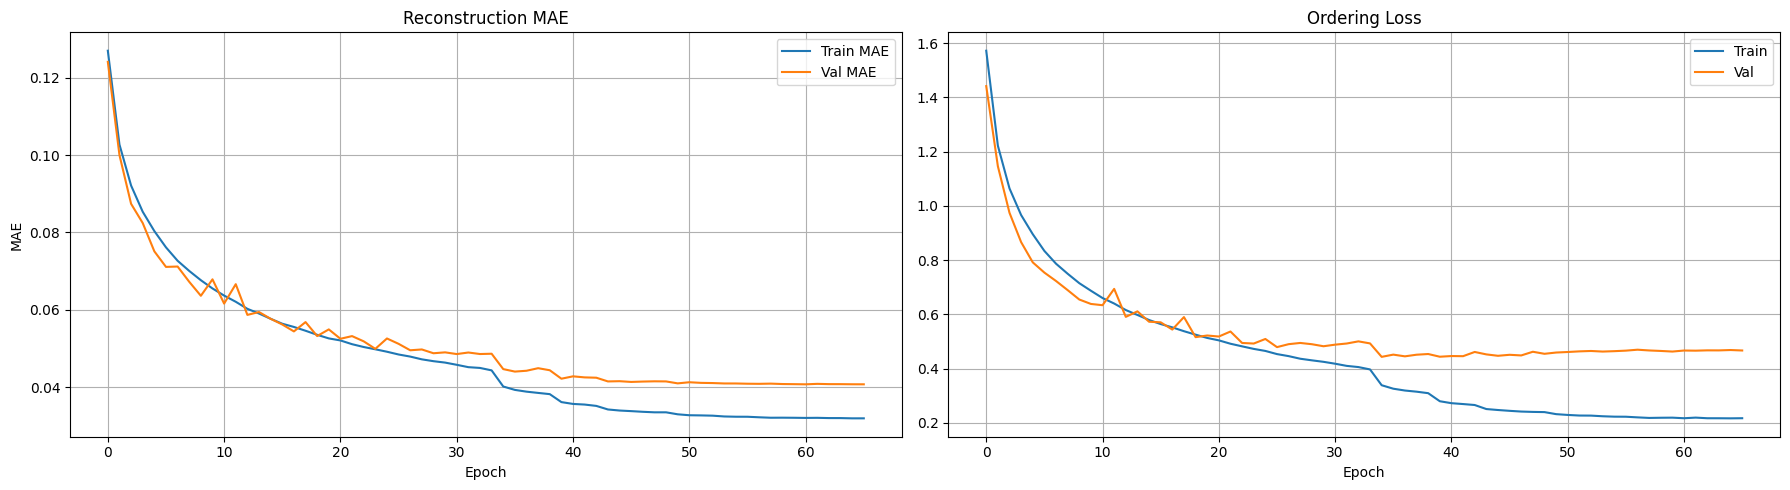

In [ ]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Reconstruction MAE
    axes[0].plot(
        history.history['reconstruction_mae'],     label='Train MAE')
    axes[0].plot(
        history.history['val_reconstruction_mae'], label='Val MAE')
    axes[0].set_title('Reconstruction MAE')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MAE')
    axes[0].legend()
    axes[0].grid(True)

    # Ordering loss
    axes[1].plot(
        history.history['ordering_loss'],     label='Train')
    axes[1].plot(
        history.history['val_ordering_loss'], label='Val')
    axes[1].set_title('Ordering Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_training_history(history)

In [ ]:
# Store per-image MAE — not per-batch
# This is correct regardless of batch size variation in last batch
per_image_mae = []

for i in range(len(test_generator)):
    X_batch, Y_batch = test_generator.__getitem__(i)

    preds      = model.predict(X_batch, verbose=0)
    pred_image = preds['reconstruction']        # (B, 96, 96, 3)
    true_image = Y_batch['reconstruction']      # (B, 96, 96, 3)

    # MAE per image: mean over H, W, C axes → one number per image
    batch_mae = np.mean(
        np.abs(pred_image - true_image),
        axis=(1, 2, 3))                         # shape: (B,)

    per_image_mae.extend(batch_mae.tolist())

per_image_mae = np.array(per_image_mae)        # shape: (10000,)

test_mae = np.mean(per_image_mae)
test_std = np.std(per_image_mae)

print(f'Test MAE              : {test_mae:.4f}')
print(f'Test Std              : {test_std:.4f}')

Test MAE              : 0.0412
Test Std              : 0.0374


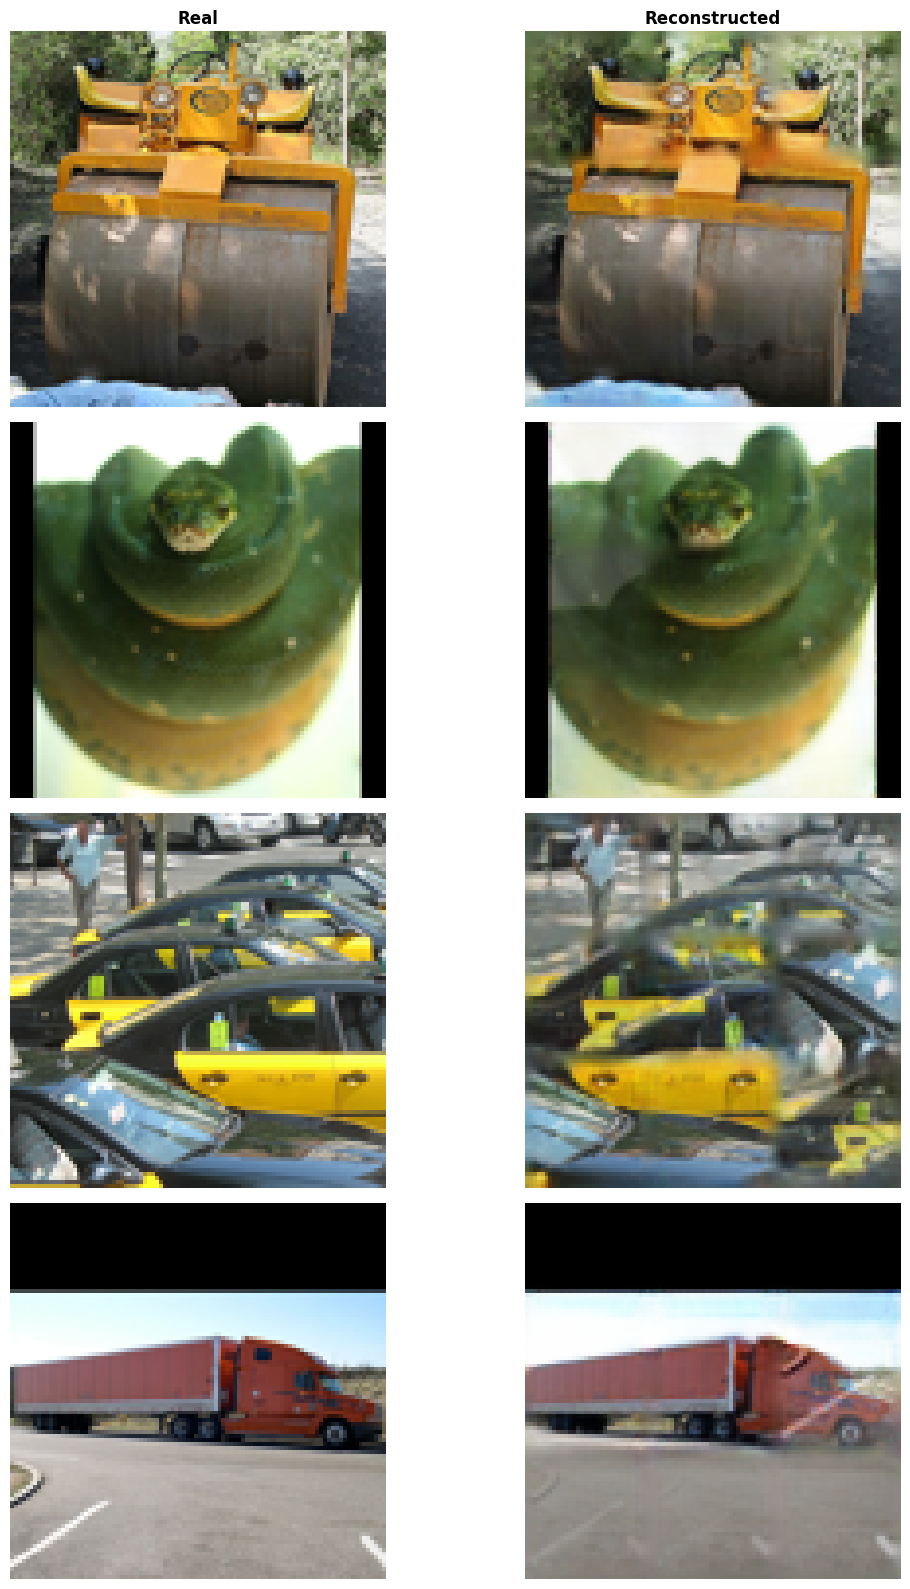

In [ ]:
def visualize_results(model, generator, n_samples=4):
    X_batch, Y_batch = generator.__getitem__(1)
    preds            = model.predict(X_batch[:n_samples], verbose=0)
    pred_images      = preds['reconstruction']
    true_images      = Y_batch['reconstruction']

    fig, axes = plt.subplots(
        n_samples, 2, figsize=(12, 4 * n_samples))

    titles = ['Real', 'Reconstructed']

    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i in range(n_samples):
        axes[i, 0].imshow(true_images[i])
        axes[i, 1].imshow(np.clip(pred_images[i], 0, 1))


        mae = np.mean(np.abs(pred_images[i] - true_images[i]))
        axes[i, 1].set_xlabel(f'MAE: {mae:.4f}', fontsize=10)

        for j in range(2):
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('reconstruction_results.png', dpi=150)
    plt.show()

visualize_results(model, test_generator)

In [ ]:
pl = model.get_layer('neural_placement')
print("Learned position_coords:")
print(np.round(pl.position_coords.numpy(), 4))
# Expected init values for corners:
# pos 0 (top-left):     [-0.667, -0.667]
# pos 2 (top-right):    [-0.667,  0.667]
# pos 6 (bottom-left):  [ 0.667, -0.667]
# pos 8 (bottom-right): [ 0.667,  0.667]
# If learned values are e.g. [-0.55, -0.55] the patch shifted inward

Learned position_coords:
[[-6.736e-01 -6.738e-01]
 [-6.736e-01 -2.000e-04]
 [-6.736e-01  6.735e-01]
 [ 1.000e-04 -6.738e-01]
 [ 0.000e+00 -2.000e-04]
 [ 0.000e+00  6.735e-01]
 [ 6.737e-01 -6.739e-01]
 [ 6.738e-01 -1.000e-04]
 [ 6.737e-01  6.736e-01]]


In [ ]:
WEIGHTS_PATH = 'jigsaw_weights_v2.weights.h5'
model.save_weights(WEIGHTS_PATH)
print(f'Weights saved: {WEIGHTS_PATH}')

Weights saved: jigsaw_weights_v2.weights.h5


In [ ]:
def verify_weights(weights_path, test_generator):
    print('Building fresh model...')
    fresh_model, _ = build_full_pipeline()
    fresh_model.compile(
        optimizer = 'adam',
        loss      = {
            'reconstruction': 'mae',
            'ordering'      : ordering_loss
        },
        loss_weights = {'reconstruction': 1.0, 'ordering': 0.1},
        metrics      = {
            'reconstruction': keras.metrics.MeanAbsoluteError(name='mae')
        }
    )

    fresh_model.load_weights(weights_path)
    print('Weights loaded successfully!')

    # Fixed batch — same idx = same scramble = reproducible MAE
    X_check, Y_check = test_generator.__getitem__(0)
    preds            = fresh_model.predict(X_check, verbose=0)

    mae = np.mean(np.abs(
        preds['reconstruction'] - Y_check['reconstruction']))

    print(f'Verification MAE : {mae:.4f}')
    print(f'Output shape     : {preds["reconstruction"].shape}')
    print(f'Output range     : '
          f'[{preds["reconstruction"].min():.3f}, '
          f'{preds["reconstruction"].max():.3f}]')
    return mae

local_mae = verify_weights(WEIGHTS_PATH, test_generator)

Building fresh model...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 324 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Weights loaded successfully!
Verification MAE : 0.0439
Output shape     : (64, 96, 96, 3)
Output range     : [0.000, 1.000]


In [ ]:
import gdown
!gdown 1yoBG2U4-IyY18cWmSJpmEaKs4Lt8-Hwh

fresh_model, _ = build_full_pipeline()
fresh_model.compile(optimizer='adam', loss='mae',
                    metrics=[keras.metrics.MeanAbsoluteError(name='mae')])

fresh_model.load_weights('jigsaw_weights_v2.weights.h5')
print('Weights loaded')

# Step 3: Compute downloaded MAE over full test set
per_image_mae = []
for i in range(len(test_generator)):
    X_batch, Y_batch = test_generator.__getitem__(i)
    pred      = fresh_model.predict(X_batch, verbose=0)
    batch_mae = np.mean(np.abs(pred['reconstruction'] - Y_batch['reconstruction']), axis=(1,2,3))
    per_image_mae.extend(batch_mae.tolist())

per_image_mae  = np.array(per_image_mae)
downloaded_mae = np.mean(per_image_mae)
downloaded_std = np.std(per_image_mae)

print(f'Downloaded Model — Test MAE : {downloaded_mae:.4f}')
print(f'Downloaded Model — Test Std : {downloaded_std:.4f}')

Downloading...
From: https://drive.google.com/uc?id=1yoBG2U4-IyY18cWmSJpmEaKs4Lt8-Hwh
To: /content/jigsaw_weights_v2.weights.h5
100% 26.1M/26.1M [00:00<00:00, 56.6MB/s]
Weights loaded
Downloaded Model — Test MAE : 0.0412
Downloaded Model — Test Std : 0.0374


BASELINE

In [ ]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [ ]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b['reconstruction']))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.18193913, shape=(), dtype=float32)
std: tf.Tensor(0.00094474753, shape=(), dtype=float32)


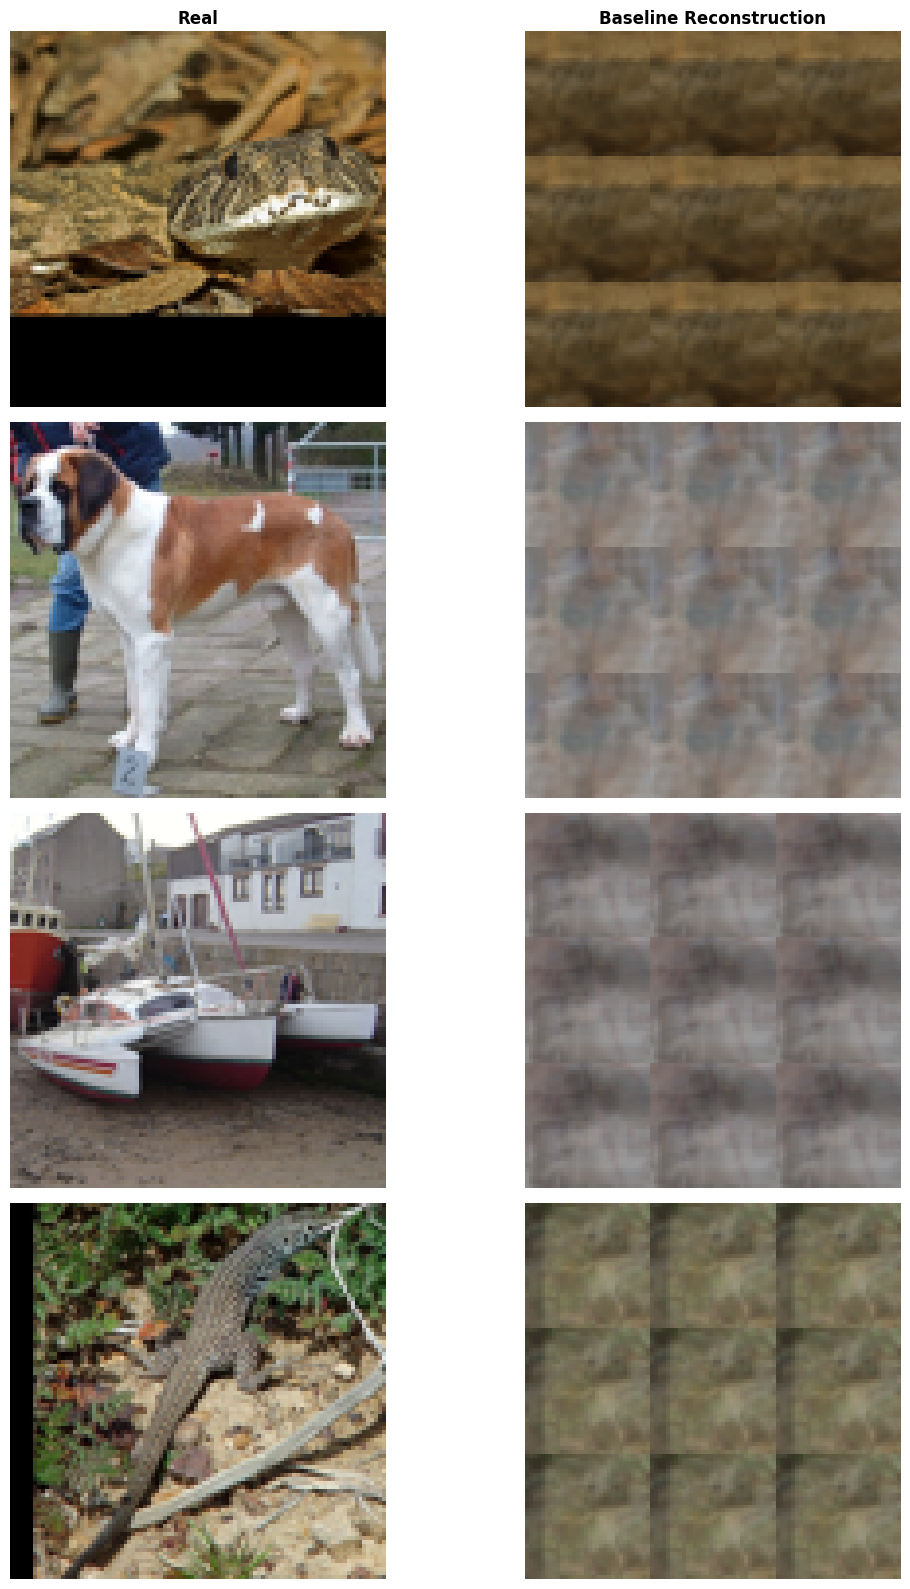

In [ ]:
def visualize_baseline_results(generator, n_samples=4):
    X_batch, Y_batch = generator.__getitem__(4)

    # Generate predictions using the mean_patch_image function for the baseline
    pred_images = mean_patch_image(X_batch[:n_samples])
    true_images = Y_batch['reconstruction'][:n_samples]

    fig, axes = plt.subplots(
        n_samples, 2, figsize=(12, 4 * n_samples))

    titles = ['Real', 'Baseline Reconstruction']

    for j, title in enumerate(titles):
        axes[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i in range(n_samples):
        axes[i, 0].imshow(true_images[i])
        axes[i, 1].imshow(np.clip(pred_images[i], 0, 1))

        mae = np.mean(np.abs(pred_images[i] - true_images[i]))
        axes[i, 1].set_xlabel(f'MAE: {mae:.4f}', fontsize=10)

        for j in range(2):
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('baseline_reconstruction_results.png', dpi=150)
    plt.show()

visualize_baseline_results(test_generator)

# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





NEW VERSION

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

class NeuralPlacementLayer(layers.Layer):
    """
    Fully neural ordering + placement layer.

    Assignment:
        A two-layer MLP maps contextual embeddings to a (B, 9, 9)
        assignment matrix via Dense → GELU → Dense → Softmax.
        Zero hand-crafted formulas.

    Placement:
        position_coords  — (9, 2) learned (y, x) centers in STN space.
        placement_scale  — (9,)   learned scale per position.
        Patches placed via standard bilinear grid sampling from
        Spatial Transformer Networks (Jaderberg et al., NeurIPS 2015).
    """

    def __init__(self, n_positions=9, patch_size=28,
                 canvas_size=96, **kwargs):
        super().__init__(**kwargs)
        self.n_positions = n_positions
        self.patch_size  = patch_size
        self.canvas_size = canvas_size

    def build(self, input_shape):
        # Learned temperature for assignment sharpness
        self.log_temp = self.add_weight(
            name='log_temperature', shape=(),
            initializer=tf.constant_initializer(0.0),
            trainable=True)

        # Learned placement coordinates - grid init run once at weight creation time
        cell  = self.canvas_size / 3.0
        inits = []
        for p in range(self.n_positions):
            row = p // 3
            col = p % 3
            y = ((row * cell + cell / 2.0) / self.canvas_size) * 2.0 - 1.0
            x = ((col * cell + cell / 2.0) / self.canvas_size) * 2.0 - 1.0
            inits.append([y, x])

        self.position_coords = self.add_weight(
            name='position_coords',
            shape=(self.n_positions, 2),
            initializer=tf.constant_initializer(
                np.array(inits, dtype=np.float32)),
            trainable=True)

        # Learned scale per position
        self.placement_scale = self.add_weight(
            name='placement_scale',
            shape=(self.n_positions,),
            initializer=tf.constant_initializer([-1.94] * self.n_positions),
            trainable=True)

        # Sub-layer objects to guarantee automatic batch-handling/broadcasting
        self.mlp_dense1 = layers.Dense(64, activation=tf.nn.gelu, name='assign_dense1')
        self.mlp_dense2 = layers.Dense(9, name='assign_dense2')
        self.softmax_layer = layers.Softmax(axis=-1)

        super().build(input_shape)

    def _assign(self, logits):
        """Pure neural assignment optimization mapping logits directly to matrix spaces."""
        temp   = tf.math.softplus(self.log_temp) + 1e-3
        scaled = logits / temp                              # (B, 9, 9)

        # Safe neural transformation handling batch shapes smoothly
        h   = self.mlp_dense1(scaled)                       # (B, 9, 64)
        out = self.mlp_dense2(h)                            # (B, 9, 9)
        return self.softmax_layer(out)

    def _bilinear_sample(self, img, grid):
        """Bilinear grid sampling — Spatial Transformer Network primitive."""
        B     = tf.shape(img)[0]
        H_in  = tf.shape(img)[1]
        W_in  = tf.shape(img)[2]
        H_out = tf.shape(grid)[1]
        W_out = tf.shape(grid)[2]

        x = (grid[..., 0] + 1.0) * tf.cast(W_in - 1, tf.float32) / 2.0
        y = (grid[..., 1] + 1.0) * tf.cast(H_in - 1, tf.float32) / 2.0

        x0 = tf.cast(tf.floor(x), tf.int32)
        y0 = tf.cast(tf.floor(y), tf.int32)
        x1 = x0 + 1
        y1 = y0 + 1

        x0 = tf.clip_by_value(x0, 0, W_in - 1)
        x1 = tf.clip_by_value(x1, 0, W_in - 1)
        y0 = tf.clip_by_value(y0, 0, H_in - 1)
        y1 = tf.clip_by_value(y1, 0, H_in - 1)

        def gather(yi, xi):
            bidx = tf.tile(
                tf.reshape(tf.range(B), (-1, 1, 1)), (1, H_out, W_out))
            return tf.gather_nd(img, tf.stack([bidx, yi, xi], axis=-1))

        Ia = gather(y0, x0);  Ib = gather(y1, x0)
        Ic = gather(y0, x1);  Id = gather(y1, x1)

        x0f = tf.cast(x0, tf.float32);  y0f = tf.cast(y0, tf.float32)
        x1f = tf.cast(x1, tf.float32);  y1f = tf.cast(y1, tf.float32)

        wa = tf.expand_dims((x1f - x)  * (y1f - y),  -1)
        wb = tf.expand_dims((x1f - x)  * (y  - y0f), -1)
        wc = tf.expand_dims((x  - x0f) * (y1f - y),  -1)
        wd = tf.expand_dims((x  - x0f) * (y  - y0f), -1)

        return wa*Ia + wb*Ib + wc*Ic + wd*Id

    def _place_patch(self, patch, y_c, x_c, scale):
        """Differentiable coordinate mapping step."""
        B = tf.shape(patch)[0]
        H = W = self.canvas_size

        gy = tf.linspace(-1.0, 1.0, H)
        gx = tf.linspace(-1.0, 1.0, W)
        grid_x, grid_y = tf.meshgrid(gx, gy)

        py = (grid_y - y_c) / (scale + 1e-8)
        px = (grid_x - x_c) / (scale + 1e-8)

        grid   = tf.stack([px, py], axis=-1)
        grid   = tf.tile(grid[None], [B, 1, 1, 1])
        placed = self._bilinear_sample(patch, grid)

        in_b = tf.cast(
            (tf.abs(py) <= 1.0) & (tf.abs(px) <= 1.0), tf.float32)
        mask = tf.tile(in_b[None, :, :, None], [B, 1, 1, 1])

        return placed, mask

    def call(self, inputs):
        logits, patches_raw = inputs

        assignment = self._assign(logits)               # (B, 9, 9)

        parts_canvas, parts_mask = [], []
        for pos_idx in range(self.n_positions):
            w        = tf.reshape(
                assignment[:, :, pos_idx], (-1, 9, 1, 1, 1))
            composed = tf.reduce_sum(w * patches_raw, axis=1)

            y_c   = tf.clip_by_value(
                self.position_coords[pos_idx, 0], -1.2, 1.2)
            x_c   = tf.clip_by_value(
                self.position_coords[pos_idx, 1], -1.2, 1.2)
            scale = tf.math.softplus(
                self.placement_scale[pos_idx]) + 0.15

            placed, mask = self._place_patch(composed, y_c, x_c, scale)
            parts_canvas.append(placed)
            parts_mask.append(mask)

        canvas = tf.add_n(parts_canvas)
        mask   = tf.clip_by_value(tf.add_n(parts_mask), 0.0, 1.0)
        return tf.concat([canvas, mask], axis=-1), assignment

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_positions': self.n_positions,
            'patch_size' : self.patch_size,
            'canvas_size': self.canvas_size,
        })
        return config
